# 📓 Notebook 05 – PSO Hyperparameter Tuning
## Lettuce Fresh Weight Prediction | ANN + PSO

**Mode: Local (VS Code)**

Particle Swarm Optimization mencari hyperparameter ANN terbaik:
| Parameter | Search Space |
|-----------|-------------|
| Neurons Layer 1 | 16 – 128 |
| Neurons Layer 2 | 8 – 64 |
| Learning Rate   | 0.0001 – 0.01 |
| Alpha (L2 Reg)  | 0.0001 – 0.01 |

**Objective:** Minimasi RMSE (5-Fold Cross Validation)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, joblib, time
import warnings
warnings.filterwarnings('ignore')

import pyswarms as ps
from pyswarms.single import GlobalBestPSO

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.edgecolor': '#0f3460', 'grid.color': '#0f3460', 'axes.grid': True,
})
print(f'✅ PySwarms: {ps.__version__}')

✅ PySwarms: 1.3.0


In [2]:
BASE_DIR = r'D:/laragon/www/lettuce-weight-prediction'

df = pd.read_csv(f'{BASE_DIR}/data/dataset.csv')

FEATURE_COLUMNS = [
    'leaf_area', 'perimeter', 'aspect_ratio', 'extent', 'equivalent_diameter',
    'mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V', 'std_G',
    'contrast', 'energy', 'homogeneity', 'correlation', 'entropy'
]

X = df[FEATURE_COLUMNS].values
y = df['weight_gram'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler    = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'✅ Data loaded: {len(X_train)} train | {len(X_test)} test')

✅ Data loaded: 160 train | 40 test


## A. Konfigurasi PSO

In [3]:
# ── Konfigurasi PSO ─────────────────────────────────────────
# Kurangi N_PARTICLES & N_ITERS jika ingin lebih cepat

N_PARTICLES = 15    # Jumlah partikel
N_ITERS     = 30    # Jumlah iterasi
CV_FOLDS    = 5     # Fold cross-validation

# Dimensi pencarian: [n1, n2, lr, alpha]
# d=0 : neurons layer 1 (16 – 128)
# d=1 : neurons layer 2 (8 – 64)
# d=2 : learning rate   (0.0001 – 0.01)
# d=3 : alpha (L2 reg)  (0.0001 – 0.01)

BOUNDS = (
    np.array([16,   8,    0.0001, 0.0001]),  # lower
    np.array([128,  64,   0.01,   0.01  ]),  # upper
)

PSO_OPTIONS = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

total_evals = N_PARTICLES * N_ITERS * CV_FOLDS
print(f'⚙️  PSO Configuration:')
print(f'   Partikel     : {N_PARTICLES}')
print(f'   Iterasi      : {N_ITERS}')
print(f'   CV Folds     : {CV_FOLDS}')
print(f'   Total eval   : {total_evals}')
print(f'   Options      : c1={PSO_OPTIONS["c1"]}, c2={PSO_OPTIONS["c2"]}, w={PSO_OPTIONS["w"]}')
print()
print(f'   Dimensi pencarian:')
print(f'   [layer1_neurons, layer2_neurons, learning_rate, alpha]')
print(f'   Lower: {BOUNDS[0].tolist()}')
print(f'   Upper: {BOUNDS[1].tolist()}')

⚙️  PSO Configuration:
   Partikel     : 15
   Iterasi      : 30
   CV Folds     : 5
   Total eval   : 2250
   Options      : c1=0.5, c2=0.3, w=0.9

   Dimensi pencarian:
   [layer1_neurons, layer2_neurons, learning_rate, alpha]
   Lower: [16.0, 8.0, 0.0001, 0.0001]
   Upper: [128.0, 64.0, 0.01, 0.01]


## B. Objective Function

In [4]:
pso_history = []  # Log tiap evaluasi

def objective_function(params_matrix):
    """
    PSO objective function.
    params_matrix: shape (n_particles, 4) – [n1, n2, lr, alpha]
    Returns: array RMSE (n_particles,) – minimize!
    """
    costs = []
    kf    = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

    for params in params_matrix:
        n1    = max(8,  int(params[0]))
        n2    = max(4,  int(params[1]))
        lr    = float(np.clip(params[2], 1e-5, 0.1))
        alpha = float(np.clip(params[3], 1e-5, 0.1))

        fold_rmse = []
        for tr_idx, val_idx in kf.split(X_train_s):
            Xtr, Xval = X_train_s[tr_idx], X_train_s[val_idx]
            ytr, yval = y_train[tr_idx],   y_train[val_idx]

            m = MLPRegressor(
                hidden_layer_sizes=(n1, n2),
                activation='relu', solver='adam',
                learning_rate_init=lr, alpha=alpha,
                max_iter=200, random_state=42,
                early_stopping=False,
            )
            try:
                m.fit(Xtr, ytr)
                yp  = m.predict(Xval)
                fold_rmse.append(np.sqrt(mean_squared_error(yval, yp)))
            except:
                fold_rmse.append(9999)

        mean_rmse = np.mean(fold_rmse)
        costs.append(mean_rmse)
        pso_history.append({'n1': n1, 'n2': n2, 'lr': lr, 'alpha': alpha, 'rmse': mean_rmse})

    return np.array(costs)


print('✅ Objective function berhasil dibuat!')
print('   (Minimize RMSE via 5-Fold CV)')

✅ Objective function berhasil dibuat!
   (Minimize RMSE via 5-Fold CV)


## C. Jalankan PSO

In [5]:
print(f'🚀 Memulai PSO Optimization...')
print(f'   ⏳ Estimasi waktu: {N_PARTICLES * N_ITERS * 0.5:.0f}–{N_PARTICLES * N_ITERS * 2:.0f} detik')
print()

optimizer = GlobalBestPSO(
    n_particles = N_PARTICLES,
    dimensions  = 4,
    options     = PSO_OPTIONS,
    bounds      = BOUNDS,
)

t_start   = time.time()
best_cost, best_pos = optimizer.optimize(objective_function, iters=N_ITERS, verbose=True)
t_elapsed = time.time() - t_start

# Decode best params
BEST_N1    = max(8, int(best_pos[0]))
BEST_N2    = max(4, int(best_pos[1]))
BEST_LR    = float(np.clip(best_pos[2], 1e-5, 0.1))
BEST_ALPHA = float(np.clip(best_pos[3], 1e-5, 0.1))

print(f'\n✅ PSO Selesai! (Waktu: {t_elapsed:.1f}s)')
print(f'\n🏆 HYPERPARAMETER TERBAIK:')
print(f'  Layer 1 Neurons : {BEST_N1}')
print(f'  Layer 2 Neurons : {BEST_N2}')
print(f'  Learning Rate   : {BEST_LR:.6f}')
print(f'  Alpha (L2 Reg)  : {BEST_ALPHA:.6f}')
print(f'  Best RMSE (CV)  : {best_cost:.4f} gram')

2026-05-29 18:16:02,355 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


🚀 Memulai PSO Optimization...
   ⏳ Estimasi waktu: 225–900 detik



pyswarms.single.global_best: 100%|██████████|30/30, best_cost=3.54
2026-05-29 18:17:11,728 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 3.535646649811877, best pos: [1.21706364e+02 4.58432733e+01 9.20231637e-03 9.90481813e-03]



✅ PSO Selesai! (Waktu: 69.4s)

🏆 HYPERPARAMETER TERBAIK:
  Layer 1 Neurons : 121
  Layer 2 Neurons : 45
  Learning Rate   : 0.009202
  Alpha (L2 Reg)  : 0.009905
  Best RMSE (CV)  : 3.5356 gram


In [6]:
# Training ulang model dengan hyperparameter PSO terbaik
ann_pso = MLPRegressor(
    hidden_layer_sizes=(BEST_N1, BEST_N2),
    activation='relu', solver='adam',
    learning_rate='adaptive',
    learning_rate_init=BEST_LR,
    alpha=BEST_ALPHA,
    max_iter=500,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
    random_state=42
)

ann_pso.fit(X_train_s, y_train)

y_pred_pso = ann_pso.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred_pso)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_pso))
r2   = r2_score(y_test, y_pred_pso)
mape = np.mean(np.abs((y_test - y_pred_pso) / (y_test + 1e-10))) * 100

print('📊 PERFORMA ANN+PSO (Test Set):')
print(f'  MAE  : {mae:.4f} gram')
print(f'  RMSE : {rmse:.4f} gram')
print(f'  R²   : {r2:.4f}')
print(f'  MAPE : {mape:.2f}%')

# Simpan model
joblib.dump(ann_pso, f'{BASE_DIR}/output/models/ann_model_pso_optimized.pkl')
print(f'\n✅ PSO Model disimpan → output/models/ann_model_pso_optimized.pkl')

📊 PERFORMA ANN+PSO (Test Set):
  MAE  : 2.8100 gram
  RMSE : 3.3885 gram
  R²   : 0.6809
  MAPE : 9.05%

✅ PSO Model disimpan → output/models/ann_model_pso_optimized.pkl


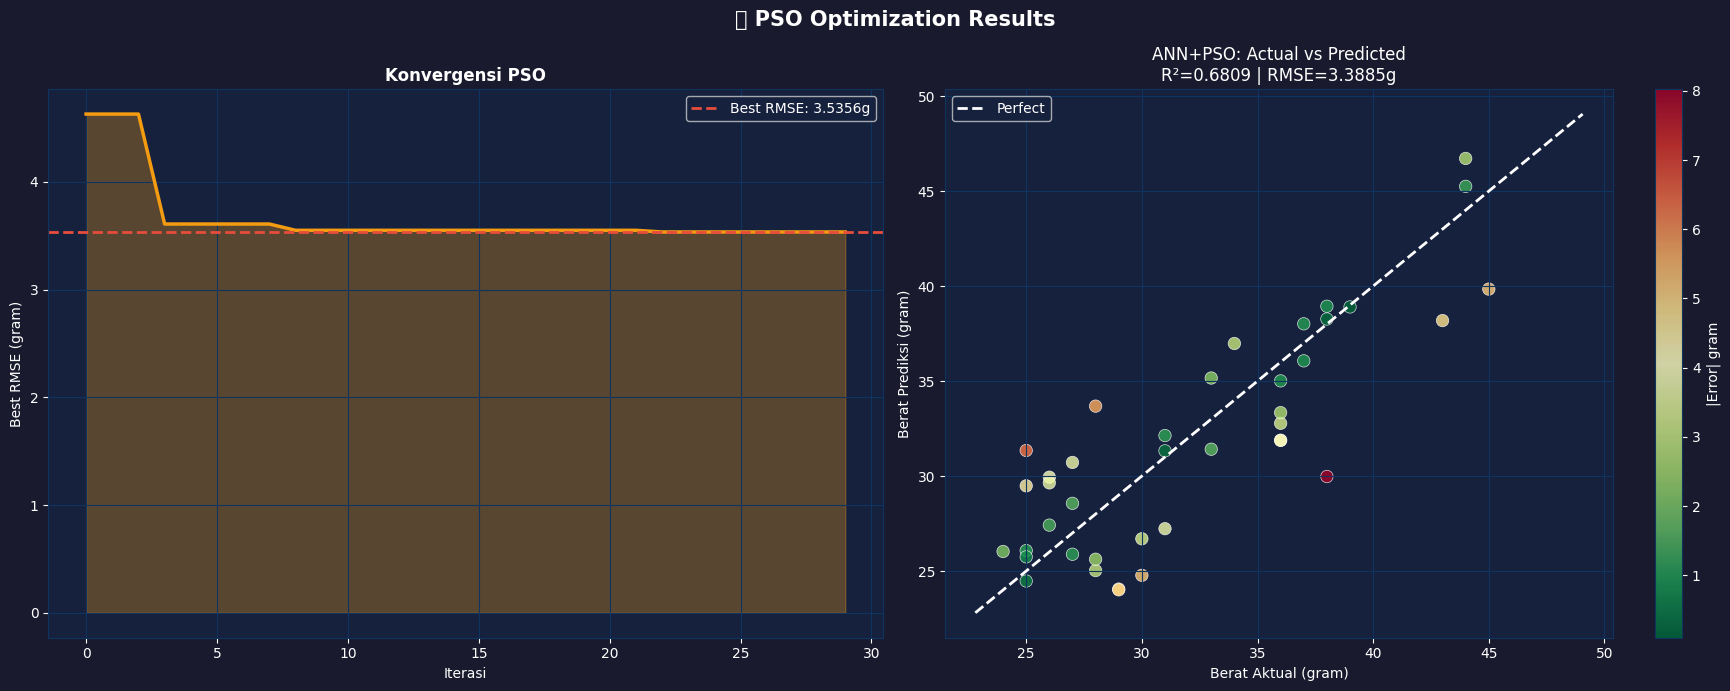

✅ Simpan → output/plots/pso_convergence.png

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
✅ NOTEBOOK 05 SELESAI!
  Best Arch      : (121, 45)
  Best LR        : 0.009202
  Best Alpha     : 0.009905
  PSO RMSE (CV)  : 3.5356g
  Test R²        : 0.6809

📌 Lanjut → 06_Model_Evaluation.ipynb


In [7]:
# Visualisasi konvergensi PSO
cost_history = optimizer.cost_history

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🐝 PSO Optimization Results', fontsize=15, fontweight='bold', color='white')

# Convergence curve
axes[0].plot(cost_history, color='#F39C12', lw=2.5)
axes[0].fill_between(range(len(cost_history)), cost_history, alpha=0.3, color='#F39C12')
axes[0].axhline(best_cost, color='#E74C3C', ls='--', lw=2, label=f'Best RMSE: {best_cost:.4f}g')
axes[0].set_title('Konvergensi PSO', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iterasi'); axes[0].set_ylabel('Best RMSE (gram)')
axes[0].legend()

# Actual vs Predicted (PSO model)
err = np.abs(y_test - y_pred_pso)
sc  = axes[1].scatter(y_test, y_pred_pso, c=err, cmap='RdYlGn_r', s=80, alpha=0.8, edgecolors='white', lw=0.5)
plt.colorbar(sc, ax=axes[1], label='|Error| gram')
lim = [min(y_test.min(), y_pred_pso.min())*0.95, max(y_test.max(), y_pred_pso.max())*1.05]
axes[1].plot(lim, lim, 'w--', lw=2, label='Perfect')
axes[1].set_title(f'ANN+PSO: Actual vs Predicted\nR²={r2:.4f} | RMSE={rmse:.4f}g', fontsize=12)
axes[1].set_xlabel('Berat Aktual (gram)'); axes[1].set_ylabel('Berat Prediksi (gram)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/pso_convergence.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/pso_convergence.png')

print('\n=' * 55)
print('✅ NOTEBOOK 05 SELESAI!')
print('=' * 55)
print(f'  Best Arch      : ({BEST_N1}, {BEST_N2})')
print(f'  Best LR        : {BEST_LR:.6f}')
print(f'  Best Alpha     : {BEST_ALPHA:.6f}')
print(f'  PSO RMSE (CV)  : {best_cost:.4f}g')
print(f'  Test R²        : {r2:.4f}')
print()
print('📌 Lanjut → 06_Model_Evaluation.ipynb')